In [1]:
import geopandas as gpd
import numpy as np

In [2]:
df = gpd.read_file("../data/census_tract_data_2024.csv")

In [3]:
columns = ['NAME', 'median_income', 'total_pop', 'total_households',
       'households_no_vehicle', 'total_pop_race', 'white_alone', 'state',
       'county', 'tract', 'county_name', 'pct_no_vehicle', 'pct_nonwhite',
       'GEOID', 'tract_lat', 'tract_lon']

In [4]:
set(columns) - set(df.columns)

{'median_income', 'tract_lat', 'tract_lon'}

In [5]:
tracts = gpd.read_file("../data/tl_2024_06_tract/tl_2024_06_tract.shp")

In [6]:
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,0,+37.5371513,-122.0081095,"POLYGON ((-122.01721 37.53932, -122.01719 37.5..."
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,0,+37.5293619,-121.9931002,"POLYGON ((-122.0023 37.52984, -122.00224 37.52..."
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,0,+34.0175004,-118.1974975,"POLYGON ((-118.20284 34.01966, -118.20283 34.0..."
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,0,+34.0245059,-118.2142985,"POLYGON ((-118.21964 34.02628, -118.21945 34.0..."
4,06,037,205120,06037205120,1400000US06037205120,2051.20,Census Tract 2051.20,G5020,S,1466242,0,+34.0187542,-118.2117951,"POLYGON ((-118.22023 34.02056, -118.22018 34.0..."


In [8]:
bay_fips = ['001','013','041','055','075','081','085','095','097']

bay_tracts = tracts[
    (tracts['STATEFP'] == '06') &
    (tracts['COUNTYFP'].isin(bay_fips))
]

<Axes: >

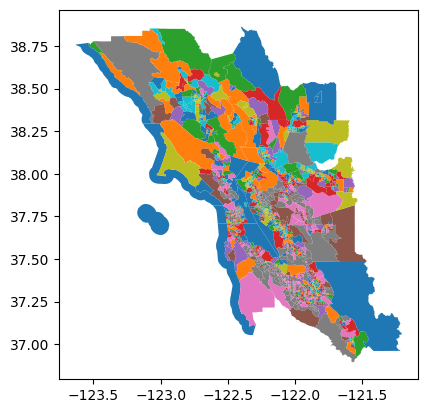

In [9]:
census = bay_tracts.merge(df, on="GEOID")
census.plot(column='median_household_income')

In [11]:
import pandas as pd
import numpy as np
from math import radians, cos, sin, asin, sqrt
from scipy import stats

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def haversine(lon1, lat1, lon2, lat2):
    """Distance in meters between two lat/lon points."""
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371000


def classify_station(row):
    """
    Classify each station as peripheral or core.
    Peripheral = outer Bay Area (eastern Contra Costa, southern Santa Clara).
    """
    peripheral_cities = [
        "antioch", "pittsburg", "bay point", "north concord", "concord",
        "pleasant hill", "walnut creek", "san jose", "milpitas",
        "warm springs", "fremont", "union city", "dublin",
        "pleasanton", "livermore", "gilroy", "morgan hill", "berryessa"
    ]
    city   = str(row.get("city", "")).lower()
    county = str(row.get("county", "")).lower().replace(" ", "")
    if county in ["contracosta", "santaclara"] or any(c in city for c in peripheral_cities):
        return "peripheral"
    return "core"


def nearest_census_tract(station_lat, station_lon, census_df):
    """Return the index of the census tract centroid closest to the station."""
    dists = census_df.apply(
        lambda r: haversine(station_lon, station_lat, r["tract_lon"], r["tract_lat"]),
        axis=1
    )
    return dists.idxmin()


# ============================================================
# STEP 1 — LOAD DATA
# ============================================================

transit   = pd.read_csv("../data/transit_gdf.csv")
amenities = pd.read_csv("../data/all_amenities.csv")
#census    = pd.read_csv("../data/bay_area_census_tracts.csv")  # or however you load your GeoDataFrame

print(f"  {len(transit)} transit stations")
print(f"  {len(amenities)} amenities")
print(f"  {len(census)} census tracts\n")

# Fix county name inconsistency in transit data
transit["county"] = transit["county"].str.lower().str.replace(" ", "")

# Classify stations as peripheral or core
transit["station_type"] = transit.apply(classify_station, axis=1)
print("Station type breakdown:")
print(transit["station_type"].value_counts(), "\n")


# ============================================================
# STEP 2 — PREPARE CENSUS TRACT CENTROIDS
# Use the real INTPTLAT / INTPTLON interior point coordinates
# instead of the previous county-centroid + jitter approach.
# ============================================================

census["tract_lat"] = pd.to_numeric(census["INTPTLAT"], errors="coerce")
census["tract_lon"] = pd.to_numeric(census["INTPTLON"], errors="coerce")

# Drop tracts missing centroid coordinates
census = census.dropna(subset=["tract_lat", "tract_lon"]).reset_index(drop=True)
print(f"  {len(census)} census tracts with valid centroids\n")


# ============================================================
# STEP 3 — BUFFER ANALYSIS: COUNT AMENITIES WITHIN 0.5 MILES
# ============================================================

HALF_MILE  = 804.67   # meters
ESSENTIAL  = ["grocery", "park", "clinic", "pharmacy"]

results = []
print("Calculating amenity buffers for each station...")

for idx, station in transit.iterrows():
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/{len(transit)} stations...")

    slat, slon = station["latitude"], station["longitude"]

    amenities["distance"] = amenities.apply(
        lambda row: haversine(slon, slat, row["longitude"], row["latitude"]),
        axis=1
    )

    within = amenities[amenities["distance"] <= HALF_MILE].copy()
    counts = within["category"].value_counts().to_dict()

    diversity_score  = sum(1 for cat in ESSENTIAL if counts.get(cat, 0) > 0)
    nearest_dist     = within["distance"].min() if len(within) > 0 else np.nan

    result = {
        "station_name":      station["name"],
        "station_id":        station.get("station_id", idx),
        "agency":            station["agency"],
        "city":              station.get("city", "Unknown"),
        "county":            station["county"],
        "latitude":          slat,
        "longitude":         slon,
        "station_type":      station["station_type"],
        "total_amenities":   len(within),
        "diversity_score":   diversity_score,
        "nearest_amenity_m": nearest_dist,
        "grocery":           counts.get("grocery", 0),
        "park":              counts.get("park", 0),
        "clinic":            counts.get("clinic", 0),
        "pharmacy":          counts.get("pharmacy", 0),
        "hospital":          counts.get("hospital", 0),
        "doctors":           counts.get("doctors", 0),
        "childcare":         counts.get("childcare", 0),
        "kindergartens":     counts.get("kindergartens", 0),
        "convenience":       counts.get("convenience", 0),
    }
    results.append(result)

results_df = pd.DataFrame(results)


# ============================================================
# STEP 4 — JOIN CENSUS DEMOGRAPHICS TO EACH STATION
# Column name changes vs. original:
#   median_income           → median_household_income
#   (tract centroids now come from INTPTLAT / INTPTLON)
# ============================================================

print("\nJoining census demographics to stations...")
census_matches = []

for _, station in results_df.iterrows():
    nearest_idx = nearest_census_tract(station["latitude"], station["longitude"], census)
    tract = census.loc[nearest_idx]
    census_matches.append({
        "station_name":          station["station_name"],
        "median_income":         tract["median_household_income"],   # ← renamed column
        "total_pop":             tract["total_pop"],
        "total_households":      tract["total_households"],
        "households_no_vehicle": tract["households_no_vehicle"],
        "pct_no_vehicle":        tract["pct_no_vehicle"],
        "pct_nonwhite":          tract["pct_nonwhite"],
        "GEOID":                 tract["GEOID"],
    })


results_df = results_df.merge(pd.DataFrame(census_matches), on="station_name", how="left")

# Ensure numeric types after merge
for col in ["total_pop", "total_households", "households_no_vehicle",
            "pct_no_vehicle", "pct_nonwhite", "median_income"]:
    results_df[col] = pd.to_numeric(results_df[col], errors="coerce")


# Normalised access metric: amenities per 1,000 residents
results_df["amenities_per_1000"] = (
    results_df["total_amenities"] / results_df["total_pop"] * 1000
).replace([np.inf, -np.inf], np.nan)

results_df = results_df.sort_values("total_amenities", ascending=False)


# ============================================================
# STEP 5 — ORIGINAL OUTPUT (preserved)
# ============================================================

SEP = "=" * 90

print(f"\n{SEP}")
print("AMENITIES WITHIN HALF MILE (0.5 mi = 804.67 m) OF EACH TRANSIT STATION")
print(SEP)
print(f"\nTotal stations analyzed: {len(results_df)}")

print(f"\n{SEP}\nTOP 15 STATIONS BY TOTAL AMENITIES\n{SEP}")
print(results_df[["station_name","agency","total_amenities",
                   "hospital","clinic","doctors","pharmacy"]].head(15).to_string(index=False))

print(f"\n{SEP}\nBOTTOM 10 STATIONS BY AMENITIES\n{SEP}")
print(results_df[["station_name","agency","total_amenities",
                   "hospital","clinic","doctors","pharmacy"]].tail(10).to_string(index=False))

print(f"\n{SEP}\nSUMMARY STATISTICS\n{SEP}")
print(f"Average amenities per station : {results_df['total_amenities'].mean():.1f}")
print(f"Median amenities per station  : {results_df['total_amenities'].median():.1f}")
print(f"Standard deviation            : {results_df['total_amenities'].std():.1f}")
print(f"Max amenities at one station  : {results_df['total_amenities'].max()}")
print(f"Station with most amenities   : {results_df.iloc[0]['station_name']} ({results_df.iloc[0]['agency']})")
print(f"Stations with NO amenities    : {(results_df['total_amenities'] == 0).sum()}")
print(f"Stations with 10+ amenities   : {(results_df['total_amenities'] >= 10).sum()}")
print(f"Stations with 50+ amenities   : {(results_df['total_amenities'] >= 50).sum()}")

print(f"\n{SEP}\nAVERAGE AMENITIES BY TRANSIT AGENCY\n{SEP}")
print(results_df.groupby("agency").agg(
    total_amenities_mean   =("total_amenities","mean"),
    total_amenities_median =("total_amenities","median"),
    total_amenities_min    =("total_amenities","min"),
    total_amenities_max    =("total_amenities","max"),
    hospital_mean          =("hospital","mean"),
    clinic_mean            =("clinic","mean"),
    doctors_mean           =("doctors","mean"),
    pharmacy_mean          =("pharmacy","mean"),
).round(1).to_string())

results_df["healthcare_total"] = results_df["hospital"] + results_df["clinic"]
print(f"\n{SEP}\nSTATIONS WITH BEST HEALTHCARE ACCESS (hospitals + clinics)\n{SEP}")
print(results_df.nlargest(10, "healthcare_total")[
    ["station_name","agency","hospital","clinic","healthcare_total"]
].to_string(index=False))


# ============================================================
# STEP 6 — PERIPHERAL vs CORE COMPARISON
# ============================================================

print(f"\n{SEP}\nPERIPHERAL vs CORE STATION COMPARISON\n{SEP}")
print(results_df.groupby("station_type").agg(
    n_stations            =("station_name","count"),
    avg_total_amenities   =("total_amenities","mean"),
    avg_grocery           =("grocery","mean"),
    avg_park              =("park","mean"),
    avg_clinic            =("clinic","mean"),
    avg_pharmacy          =("pharmacy","mean"),
    avg_diversity_score   =("diversity_score","mean"),
    avg_amenities_per_1000=("amenities_per_1000","mean"),
    avg_median_income     =("median_income","mean"),
    avg_pct_no_vehicle    =("pct_no_vehicle","mean"),
    avg_pct_nonwhite      =("pct_nonwhite","mean"),
).round(2).to_string())


# ============================================================
# STEP 7 — CORRELATION ANALYSIS
# ============================================================

print(f"\n{SEP}\nCORRELATION ANALYSIS\n{SEP}")

corr_targets = {
    "total_amenities": "Total Amenities",
    "diversity_score": "Diversity Score (0-4)",
}
corr_predictors = {
    "median_income":  "Median Income",
    "pct_no_vehicle": "% Households No Vehicle",
    "pct_nonwhite":   "% Non-White Population",
    "total_pop":      "Total Population",
}

for target_col, target_label in corr_targets.items():
    print(f"\n  Correlations with {target_label}:")
    for pred_col, pred_label in corr_predictors.items():
        clean = results_df[[target_col, pred_col]].dropna()
        if len(clean) < 5:
            continue
        r, p = stats.pearsonr(clean[target_col], clean[pred_col])
        sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "(ns)"
        print(f"    vs {pred_label:<30}  r = {r:+.3f},  p = {p:.4f}  {sig}")


# ============================================================
# STEP 8 — T-TESTS / MANN-WHITNEY (PERIPHERAL vs CORE)
# ============================================================

print(f"\n{SEP}\nT-TEST: PERIPHERAL vs CORE STATIONS\n{SEP}")
print("Null hypothesis: no difference in means between peripheral and core stations\n")

core_df = results_df[results_df["station_type"] == "core"]
peri_df = results_df[results_df["station_type"] == "peripheral"]

ttest_vars = {
    "total_amenities":    "Total Amenities",
    "diversity_score":    "Diversity Score",
    "grocery":            "Grocery Stores",
    "park":               "Parks",
    "clinic":             "Clinics",
    "pharmacy":           "Pharmacies",
    "amenities_per_1000": "Amenities per 1,000 Residents",
    "median_income":      "Median Income",
    "pct_no_vehicle":     "% No Vehicle",
    "pct_nonwhite":       "% Non-White",
}

for col, label in ttest_vars.items():
    c_vals = core_df[col].dropna()
    p_vals_raw = peri_df[col].dropna()
    if len(c_vals) < 3 or len(p_vals_raw) < 3:
        continue

    stat, p_val = stats.mannwhitneyu(c_vals, p_vals_raw, alternative="two-sided")
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "(ns)"

    pooled_std = np.sqrt((c_vals.std()**2 + p_vals_raw.std()**2) / 2)
    d = (c_vals.mean() - p_vals_raw.mean()) / pooled_std if pooled_std > 0 else np.nan
    effect = "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5 else "small"

    print(f"  {label}")
    print(f"    Core mean={c_vals.mean():.2f}  |  Peripheral mean={p_vals_raw.mean():.2f}")
    print(f"    Mann-Whitney U={stat:.1f}, p={p_val:.4f}  {sig}  |  Cohen's d={d:.3f} ({effect})")
    print()


# ============================================================
# STEP 9 — MULTIPLE REGRESSION
# ============================================================

print(f"\n{SEP}\nMULTIPLE REGRESSION: PREDICTORS OF TOTAL AMENITIES\n{SEP}")
print("Dependent  : total_amenities")
print("Predictors : median_income, pct_no_vehicle, pct_nonwhite, total_pop, is_peripheral\n")

reg_df = results_df[[
    "total_amenities","median_income","pct_no_vehicle",
    "pct_nonwhite","total_pop","station_type"
]].dropna().copy()

reg_df["is_peripheral"] = (reg_df["station_type"] == "peripheral").astype(int)

predictors = ["median_income","pct_no_vehicle","pct_nonwhite","total_pop","is_peripheral"]

# Standardise predictors — drop any with zero variance (would cause singular matrix)
pred_z = []
var_labels = ["(Intercept)"]
for col in predictors:
    mu, sd = reg_df[col].mean(), reg_df[col].std()
    if sd == 0:
        print(f"  WARNING: '{col}' has zero variance after filtering — dropping from regression.")
        continue
    reg_df[f"{col}_z"] = (reg_df[col] - mu) / sd
    pred_z.append(f"{col}_z")
    var_labels.append(f"{col} (z)")

X = np.column_stack([np.ones(len(reg_df))] + [reg_df[p].values for p in pred_z])
y = reg_df["total_amenities"].values

# Check rank before inverting
rank = np.linalg.matrix_rank(X)
if rank < X.shape[1]:
    print(f"  WARNING: Design matrix is rank-deficient ({rank} < {X.shape[1]}). ")
    print("  This usually means perfect collinearity. Check your predictors.\n")

coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

y_hat  = X @ coeffs
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
n, k   = X.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k) if ss_tot > 0 else np.nan

print(f"  R-squared      : {r2:.4f}")
print(f"  Adj. R-squared : {adj_r2:.4f}")
print(f"  n observations : {n}\n")

# Use pseudoinverse instead of inv — handles singular/near-singular matrices gracefully
mse    = ss_res / (n - k) if n > k else np.nan
cov    = mse * np.linalg.pinv(X.T @ X)
se     = np.sqrt(np.diag(cov))
t_vals = coeffs / se
p_vals_reg = [2 * (1 - stats.t.cdf(abs(t), df=n - k)) for t in t_vals]

print(f"  {'Variable':<22} {'Coeff':>8} {'SE':>8} {'t':>8} {'p':>9}  Sig")
print(f"  {'-'*65}")
for label, coef, se_val, t_val, p_val in zip(var_labels, coeffs, se, t_vals, p_vals_reg):
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"  {label:<22} {coef:>8.3f} {se_val:>8.3f} {t_val:>8.3f} {p_val:>9.4f}  {sig}")

print("\n  *** p<0.001  ** p<0.01  * p<0.05")


# ============================================================
# STEP 10 — EQUITY FLAGS
# ============================================================

print(f"\n{SEP}\nEQUITY FLAGS: LOW AMENITIES + DISADVANTAGED DEMOGRAPHICS\n{SEP}")
print("Flagged = below-median amenities AND (above-median % non-white OR above-median % no vehicle)\n")

med_amenities  = results_df["total_amenities"].median()
med_nonwhite   = results_df["pct_nonwhite"].median()
med_no_vehicle = results_df["pct_no_vehicle"].median()

results_df["equity_flag"] = (
    (results_df["total_amenities"] < med_amenities) &
    (
        (results_df["pct_nonwhite"]   > med_nonwhite) |
        (results_df["pct_no_vehicle"] > med_no_vehicle)
    )
)

flagged = results_df[results_df["equity_flag"]].sort_values("total_amenities")
print(f"  {len(flagged)} of {len(results_df)} stations flagged\n")
print(flagged[[
    "station_name","agency","station_type",
    "total_amenities","diversity_score",
    "pct_nonwhite","pct_no_vehicle","median_income"
]].to_string(index=False))

  81 transit stations
  11360 amenities
  1772 census tracts

Station type breakdown:
station_type
core          62
peripheral    19
Name: count, dtype: int64 

  1772 census tracts with valid centroids

Calculating amenity buffers for each station...
  Processed 10/81 stations...
  Processed 20/81 stations...
  Processed 30/81 stations...
  Processed 40/81 stations...
  Processed 50/81 stations...
  Processed 60/81 stations...
  Processed 70/81 stations...
  Processed 80/81 stations...

Joining census demographics to stations...

AMENITIES WITHIN HALF MILE (0.5 mi = 804.67 m) OF EACH TRANSIT STATION

Total stations analyzed: 83

TOP 15 STATIONS BY TOTAL AMENITIES
                  station_name   agency  total_amenities  hospital  clinic  doctors  pharmacy
         Civic Center/UN Plaza     BART               68         0       7        3         1
                    Powell St.     BART               66         0       3        4         2
  12th St. Oakland City Center     BART      